# A quick tutorial on how to use Fluxplot, with some basic examples

The idea here is that we will go through a few very simple plotting examples and first show you how it may be done the "traditional" way, and then show you how a bit of very basic Fluxplot code can "wrap" matplotlib figures you already have and make them much more functional when used in Flux-figure or Flux-slides.

## What Fluxplot actually adds

When matplotlib exports an SVG, it writes a flat soup of anonymous shapes — `<g id="line2d_7">`, `<g id="patch_12">`. Looking at the rendered picture *you* know that one path is "the 1 Hz wave" and that box is "the peaches"; **the file doesn't**. That meaning existed in your code at plot time — you had the arrays, the series names, the axis scales — and it was thrown away the moment the figure was flattened into anonymous geometry.

Fluxplot keeps it. You still plot in ordinary matplotlib; you just tell fluxplot *what each mark means* as you draw it. Then `fp.save()` writes **three sibling files**:

| file | what it is |
|---|---|
| `myplot.svg` | a completely normal SVG (opens anywhere) — but every meaningful part has a stable, human-readable id (`1hz.line`, `peaches.box`, `axis.x.title`) plus `data-role` / `data-series` attributes |
| `myplot.fluxplot.json` | the **manifest** — the data behind the marks, the data↔pixel coordinate mapping for each axis, the full parts inventory, and a default build order for animation |
| `myplot.recipe.json` | the **recipe** — how the plot was made (script, parameters, input-file hashes), so it can be regenerated |

Everything downstream in Flux hangs off those names:

- **Flux Figure** inlines the SVG, so you can click a part (say, "the parietal band") and restyle it — and because the override is keyed to the stable id, it **survives regenerating the plot** with new data or parameters.
- **Flux Slide** reads the manifest to animate by role ("draw every line, then fade the bands in") and to **morph** one version of a plot into another in *data space* (log-axis aware), using the per-axis coordinate anchors.
- **An agent** (or you, in a terminal) can address "the 4th point of the control series" as a real handle, read its value from the manifest, or re-run the recipe with different parameters.

Two ideas to keep in mind through the examples:

1. **Role vs. identity.** Every tagged part records *what kind of thing it is* (`line`, `point`, `box`, `axis-title` — its **role**) and *which one it is* (`series="1hz"`, `index=3` — its **identity**). Animations usually target roles ("stagger all points in"); captions and restyles usually target identities ("the treatment series").
2. **Meaning is captured at plot time, never reverse-engineered.** Fluxplot tags artists while your code still knows what they are; nothing is ever guessed from pixels afterwards.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import fluxplot as fp  # ← the semantic layer used in the "Fluxplot way" sections

In [2]:
from fluxplot import style as fx
fx.use_light()

In [3]:
#Set some plotting basics:
#plt.rcdefaults()
#plt.rcParams['font.size'] = 7
#plt.rcParams['axes.spines.right'] = False
#plt.rcParams['axes.spines.top'] = False

## A basic Matplotlib lineplot

### Traditional Way

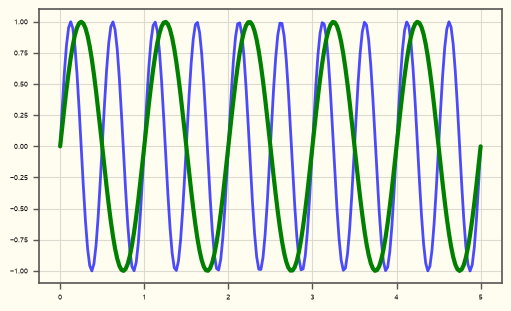

In [4]:
# create a sine wave at 1 Hz with 200 samples over 5 seconds
sine_wave_1hz = np.sin(2 * np.pi * 1 * np.linspace(0, 5, 200))
# create a sine wave at 2 Hz with 200 samples over 5 seconds
sine_wave_2hz = np.sin(2 * np.pi * 2 * np.linspace(0, 5, 200))
#create a time dimension with the proper units
time = np.linspace(0, 5, 200)

f, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(time, sine_wave_2hz, label='2Hz', color='blue', alpha=0.7)
ax.plot(time, sine_wave_1hz, label='1Hz', color='green', linewidth=3)
fx.use_light()
f.savefig('./basic_example_output/mpl_sine_waves_VANILLA.svg', transparent=True)

### Fluxplot Way

The change is one word per call: `ax.plot(...)` becomes `fp.line(ax, ..., series="...")`. The helper calls `ax.plot` for you — it returns the real matplotlib `Line2D`, and every normal kwarg (`color`, `alpha`, `linewidth`, …) passes straight through — and records *"this artist is the `2hz` line, and this is its data"* in a registry attached to the figure.

`fp.save(fig, path)` then does everything else:

- assigns each registered mark its deterministic id (`2hz.line`, `1hz.line`);
- **auto-tags the whole scaffold** — spines, ticks, tick labels, gridlines, axis titles, legend, title — you never name those by hand;
- captures each axis's scale type, data domain, and two exact data↔pixel anchor points (this is what lets Flux morph in data space later);
- renders deterministically (same code → byte-identical file, so a regenerated plot makes a clean git diff) and writes the manifest + recipe alongside.

One convention worth adopting from the start: series names are short lowercase slugs (`"2hz"`, not `"2 Hz!"`), used **consistently across related plots** — the name becomes the durable id that restyles, captions, and animations attach to.

./basic_example_output/mpl_sine_waves_FLUXPLOT.svg
./basic_example_output/mpl_sine_waves_FLUXPLOT.fluxplot.json
./basic_example_output/mpl_sine_waves_FLUXPLOT.recipe.json


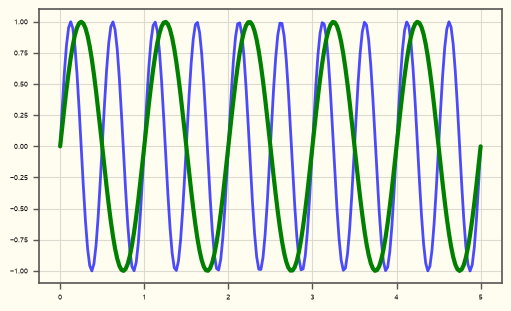

In [5]:
# same data, same look — the only change is fp.line(..., series=...) instead of ax.plot(...)
f, ax = plt.subplots(1, 1, figsize=(5, 3))
fp.line(ax, time, sine_wave_2hz, series="2hz", label='2Hz', color='blue', alpha=0.7)
fp.line(ax, time, sine_wave_1hz, series="1hz", label='1Hz', color='green', linewidth=3)

# one save call → semantic SVG + manifest + recipe
# (from a .py script you'd also pass script=__file__ so the recipe is re-runnable — see the end)
res = fp.save(f, './basic_example_output/mpl_sine_waves_FLUXPLOT.svg',
              recipe=dict(params={"freqs_hz": [1, 2], "duration_s": 5, "n_samples": 200}))
print(res.svg, res.manifest, res.recipe, sep='\n')

Same picture. The difference is what's *inside* the files. In the traditional SVG the two waves are `line2d_1` and `line2d_2` — indistinguishable from the other fifteen `line2d_*` elements (which are tick marks). In the fluxplot SVG they are named elements carrying machine-readable meaning, and the manifest records the data, the coordinate mapping, and a default animation order:

In [6]:
# the traditional file: which of these is the 1 Hz wave? nobody can know (most are tick marks!)
vanilla_ids = re.findall(r'id="([^"]+)"', Path('./basic_example_output/mpl_sine_waves_VANILLA.svg').read_text())
print("traditional:", [i for i in vanilla_ids if i.startswith('line2d')])

# the fluxplot file: the waves are named, and carry role + identity as data-* attributes
for line in Path(res.svg).read_text().splitlines():
    if 'data-series' in line:
        print("fluxplot   :", line.strip())

# the manifest knows the data behind each mark, how data maps to pixels, and how to build the plot
man = json.loads(Path(res.manifest).read_text())
print("\nseries  :", [s['id'] for s in man['series']])
print("2hz data:", man['series'][0]['data']['x'][:3], '/', man['series'][0]['data']['y'][:3], '…')
print("x-axis  :", man['axes'][0]['x']['scale'], man['axes'][0]['x']['domain'], man['axes'][0]['x']['anchors'])
print("build   :", ' → '.join(man['build']['order']))

traditional: ['line2d_1', 'line2d_2', 'line2d_3', 'line2d_4', 'line2d_5', 'line2d_6', 'line2d_7', 'line2d_8', 'line2d_9', 'line2d_10', 'line2d_11', 'line2d_12', 'line2d_13', 'line2d_14', 'line2d_15', 'line2d_16', 'line2d_17', 'line2d_18', 'line2d_19', 'line2d_20', 'line2d_21', 'line2d_22', 'line2d_23', 'line2d_24', 'line2d_25', 'line2d_26', 'line2d_27', 'line2d_28', 'line2d_29', 'line2d_30', 'line2d_31', 'line2d_32']
fluxplot   : <g id="2hz.line" data-role="line" data-series="2hz" data-kind="line">
fluxplot   : <g id="1hz.line" data-role="line" data-series="1hz" data-kind="line">

series  : ['2hz', '1hz']
2hz data: [0.0, 0.0251, 0.0503] / [0.0, 0.3105, 0.5903] …
x-axis  : linear [-0.25, 5.25] [{'data': -0.25, 'svg': 23.9602}, {'data': 5.25, 'svg': 356.9998}]
build   : axis.x → axis.y → gridlines → 2hz.line → 1hz.line


Three things worth noticing:

- **The ids are stable across regeneration.** Re-run this tomorrow with 300 samples or different amplitudes and `1hz.line` is still `1hz.line`. That's the whole trick: anything attached to that id downstream (a restyle in Flux Figure, an animation in Flux Slide, a caption reference) survives the data changing.
- **The scaffold came for free.** We never named the ticks or spines, but the SVG now contains `axis.x.tick.3`, `axis.x.ticklabel.3`, `axis.x.spine`, … — so "fade the axes in first" or "make all tick labels 8 pt" are addressable operations.
- **Points can be first-class too.** Passing `marker='o'` to `fp.line` (or using `fp.scatter`) additionally makes every marker its own element — `1hz.point.0`, `1hz.point.1`, … — each carrying its value in `data-x`/`data-y`. That's what lets Flux Slide stagger points in one-by-one, and lets an agent ask "what's the 4th point of the 1hz series?".

The other helpers work identically: `fp.scatter`, `fp.bar`, `fp.errorbar`, `fp.area` — plus the named overlays `fp.reference_line`, `fp.annotation`, and `fp.significance_bracket` (example 3).

## A seaborn lineplot, with error shading + legends + axes labels

### Traditional Way

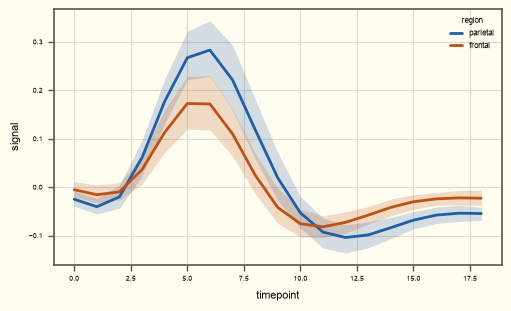

In [7]:
fmri = sns.load_dataset("fmri")
f, ax = plt.subplots(1, 1, figsize=(5, 3))
ax = sns.lineplot(data=fmri.loc[fmri['event']=='stim'], x="timepoint", y="signal", hue="region", ax=ax)
f.savefig('./basic_example_output/sns_fmri_VANILLA.svg', transparent=True)

### Fluxplot Way

Seaborn is matplotlib underneath: `sns.lineplot` here draws two ordinary `Line2D`s (the per-region means) and two `PolyCollection`s (the 95% CI bands) onto the Axes. Seaborn's API has no place to pass a `series=` through, so we use fluxplot's **escape hatch**: draw first, then name what got drawn with `fp.tag(artist, role=..., series=...)`.

`fp.tag` works on *any* matplotlib artist — so anything drawn by seaborn, pandas `.plot()`, or any other matplotlib-based library can be made semantic. The only requirement is that you do it at plot time, in the same code, where you still know which artist is which. Here that's easy: seaborn draws the lines and bands **in hue order**, and its legend preserves that order, so we can read the region names off the legend and zip everything together.

Two practical details handled below:

- seaborn also appends two **empty proxy lines** to the axes (used only to build its legend); we remove them. If we didn't, there'd be no harm — `fp.save`'s *orphan sweep* tags any leftover untagged artist as an anonymous-but-still-addressable `extra.*` element, because nothing is allowed to escape the scene graph — but naming things beats sweeping them.
- everything else — axis titles, tick labels, the legend and its per-entry swatches and labels — is auto-tagged by `fp.save`, zero work.

series: [('parietal', ['area', 'line']), ('frontal', ['area', 'line'])]
build : axis.x → axis.y → gridlines → parietal.line → frontal.line → parietal.area → frontal.area → legend


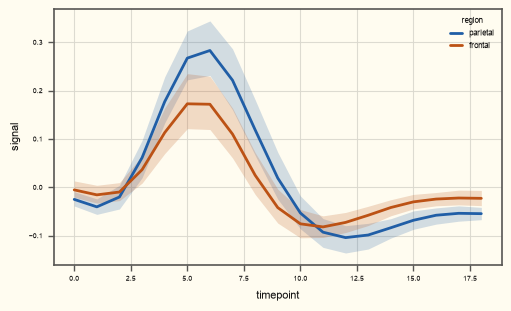

In [8]:
f, ax = plt.subplots(1, 1, figsize=(5, 3))
ax = sns.lineplot(data=fmri.loc[fmri['event']=='stim'], x="timepoint", y="signal", hue="region", ax=ax)

# the hue names, in the order seaborn drew them (the legend preserves draw order)
regions = [t.get_text() for t in ax.get_legend().get_texts()]   # ['parietal', 'frontal']

# the real mean lines carry data; seaborn's legend-only proxy lines are empty — drop those
mean_lines = [ln for ln in ax.lines if len(ln.get_xdata()) > 0]
for proxy in [ln for ln in ax.lines if len(ln.get_xdata()) == 0]:
    proxy.remove()

# name what seaborn drew: each region's mean line + CI band become addressable parts
for region, mean_line, band in zip(regions, mean_lines, ax.collections):
    fp.tag(mean_line, role="line", series=region)
    fp.tag(band, role="area", series=region)

res = fp.save(f, './basic_example_output/sns_fmri_FLUXPLOT.svg',
              recipe=dict(params={"dataset": "fmri", "event": "stim"}))

man = json.loads(Path(res.manifest).read_text())
print("series:", [(s['id'], s['roles']) for s in man['series']])
print("build :", ' → '.join(man['build']['order']))

That `build` order is literally what Flux Slide's one-click "build this plot" animation uses: axes first, then `parietal.line` / `frontal.line` draw themselves on, the CI bands fade in, then the legend — with per-role animation presets recorded in the manifest. And in Flux Figure, clicking the parietal band selects `parietal.area`; a restyle there sticks even after the plot is regenerated.

One honest limitation of the escape hatch: `fp.tag` records **identity, not data**. Seaborn computed the means and CIs internally, and fluxplot will never try to reverse-engineer numbers from pixels. The plot is fully addressable, restylable, and animatable — but if you also want the manifest to carry the numbers behind a mark (for data-space morphs, or for an agent to query values), compute the aggregate yourself and draw it with `fp.line` / `fp.area` directly.

> We wrote the tagging out by hand here to show the mechanics. In practice you don't have to — **`fp.tag_seaborn(ax)` does exactly this in one line** for the common seaborn plot types (see the dedicated example further down).

## Simple Matplotlib Boxplot

### Traditional Way

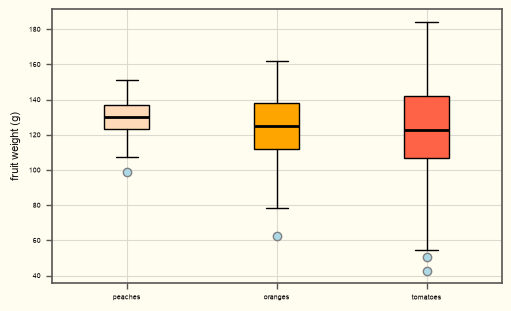

In [9]:
np.random.seed(19680801)
fruit_weights = [
    np.random.normal(130, 10, size=100),
    np.random.normal(125, 20, size=100),
    np.random.normal(120, 30, size=100),
]
labels = ['peaches', 'oranges', 'tomatoes']
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.set_ylabel('fruit weight (g)')
medianprops = dict(linestyle='-', linewidth=2, color='black')
flierprops = dict(marker='o', markerfacecolor='lightblue', markersize=6,
                  markeredgecolor='grey')

bplot = ax.boxplot(fruit_weights,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   medianprops=medianprops,
                   flierprops=flierprops)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

fig.savefig('./basic_example_output/mpl_boxplot_VANILLA.svg', transparent=True)

### Fluxplot Way

There is no fluxplot helper for box plots either — but there doesn't need to be. `ax.boxplot` returns a dict of every artist it drew (`boxes`, `medians`, `whiskers`, `caps`, `fliers`), and those component names map one-to-one onto fluxplot's core role vocabulary (`box`, `median`, `whisker`, `cap`, `flier`). So it's the example-2 pattern again: loop over the components and tag each one with its role and its series (the fruit). The one quirk to know is matplotlib's layout of the returned lists: `whiskers` and `caps` come **two per box** (lower, then upper), interleaved.

We'll also add a **first-class overlay**: `fp.significance_bracket`. Brackets are so ubiquitous in scientific figures that fluxplot draws *and* names one in a single call — and records the statistics as metadata (`between=`, `p=`), so the manifest doesn't just know a bracket exists, it knows *what claim it makes*.

tomato parts: ['tomatoes.box', 'tomatoes.whisker', 'tomatoes.whisker-2', 'tomatoes.cap', 'tomatoes.cap-2', 'tomatoes.flier', 'tomatoes.median']
overlays    : [{'between': ['peaches', 'tomatoes'], 'id': 'significance-bracket.0', 'kind': 'line', 'label': '*', 'name': '0', 'p': 0.02, 'role': 'significance-bracket', 'svgId': 'significance-bracket.0'}]


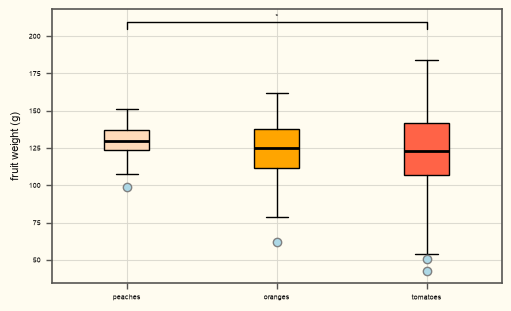

In [10]:
# same boxplot as above (reusing fruit_weights / labels / colors), plus semantic tags
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.set_ylabel('fruit weight (g)')
bplot = ax.boxplot(fruit_weights,
                   patch_artist=True,
                   tick_labels=labels,
                   medianprops=medianprops,
                   flierprops=flierprops)
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# name every component of every box (whiskers/caps come 2 per box: lower, then upper)
for k, fruit in enumerate(labels):
    fp.tag(bplot['boxes'][k],   role="box",    series=fruit)
    fp.tag(bplot['medians'][k], role="median", series=fruit)
    fp.tag(bplot['fliers'][k],  role="flier",  series=fruit)
    for whisker in bplot['whiskers'][2*k : 2*k + 2]:
        fp.tag(whisker, role="whisker", series=fruit)
    for cap in bplot['caps'][2*k : 2*k + 2]:
        fp.tag(cap, role="cap", series=fruit)

# a first-class overlay: drawn, named, and carrying its statistics as metadata
fp.significance_bracket(ax, x0=1, x1=3, y=205, label="*",
                        between=("peaches", "tomatoes"), p=0.02)

res = fp.save(fig, './basic_example_output/mpl_boxplot_FLUXPLOT.svg',
              recipe=dict(params={"n_per_group": 100, "seed": 19680801}))

# every part of every fruit is now addressable by name…
print("tomato parts:", re.findall(r'id="(tomatoes[^"]*)"', Path(res.svg).read_text()))
# …and the bracket knows what claim it makes
man = json.loads(Path(res.manifest).read_text())
print("overlays    :", man['overlays'])

(Where two sibling parts would otherwise share an id, the second gets a deterministic `-2` suffix — `tomatoes.whisker` is the lower whisker, `tomatoes.whisker-2` the upper. *Deterministic* is the key word: the same code always yields the same ids.)

This box plot is now fully live downstream: *"make every median thicker"* is a one-line restyle **by role**; *"reveal the boxes one fruit at a time"* is a stagger **by series**; and the bracket is an element a caption can point at — with its p-value machine-readably attached rather than baked into pixels.

# A few more common cases

The three pairs above cover the core idea. Here are four more patterns you'll hit constantly: a **scatter plot with overlays**, a **bar chart with error bars**, the **one-line seaborn helper**, and **multi-panel figures**. These aren't traditional/fluxplot pairs — just the fluxplot way, since by now the "before" is obvious.

## Scatter plot, with a reference line and a callout

`fp.scatter` names a whole point cloud *and* makes every point individually addressable — `samples.point.0`, `samples.point.1`, … each carrying its `(x, y)` value. On top of it we add two of fluxplot's **named overlays**: `fp.reference_line` (a labelled guide line) and `fp.annotation` (a callout that points at a specific datum). Both are ordinary matplotlib underneath (`axhline`, `annotate`) — fluxplot just gives them stable ids (`reference-line.mean-y`, `annotation.peak`) so a caption can refer to them and Flux Slide can reveal them on their own beat.

series   : samples → 60 individually addressable points
point 0  : {'index': 0, 'svgId': 'samples.point.0', 'x': 7.7396, 'y': 12.8816}
overlays : [('reference-line.mean-y', 'reference-line'), ('annotation.peak', 'annotation')]


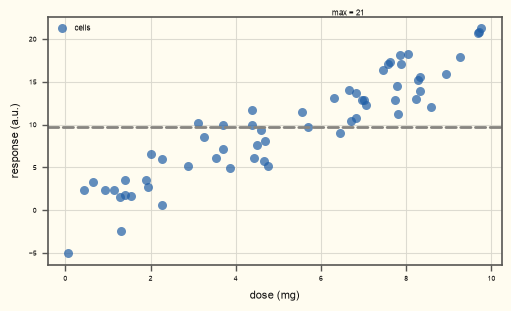

In [11]:
rng = np.random.default_rng(42)
dose = rng.uniform(0, 10, 60)
response = 2.0 * dose + rng.normal(0, 3, 60)

f, ax = plt.subplots(1, 1, figsize=(5, 3))
fp.scatter(ax, dose, response, series="samples", label="cells", alpha=0.7)

# a labelled guide line at the mean response
fp.reference_line(ax, y=float(response.mean()), name="mean-y",
                  color=fx.FLEXOKI["base500"], linestyle="--")

# a callout pointing at the strongest response
peak = int(np.argmax(response))
fp.annotation(ax, name="peak", text=f"max = {response[peak]:.0f}",
              xy=(dose[peak], response[peak]),
              xytext=(dose[peak] - 3.5, response[peak] + 1.5),
              arrowprops=dict(arrowstyle="->"))

ax.set_xlabel("dose (mg)"); ax.set_ylabel("response (a.u.)"); ax.legend()
res = fp.save(f, './basic_example_output/mpl_scatter_FLUXPLOT.svg',
              recipe=dict(params={"n": 60, "seed": 42}))

man = json.loads(Path(res.manifest).read_text())
s = man['series'][0]
print("series   :", s['id'], "→", len(s['points']), "individually addressable points")
print("point 0  :", s['points'][0])          # {index, svgId, x, y}
print("overlays :", [(o['id'], o['role']) for o in man['overlays']])

## Bar chart with error bars

`fp.bar` makes each bar its own addressable element (`viability.bar.0`, `viability.bar.1`, …), and `fp.errorbar` adds matching error bars as a tagged part of the same series. Reusing the **same `series=` name** for both is what ties them together in the manifest — so "the viability series" means the bars *and* their errors.

One thing to know: fluxplot stores each mark's raw x-values in the manifest, and the coordinate anchors assume a numeric axis, so pass **numeric bar positions** (`np.arange(3)`) and set the category names as tick labels — the usual matplotlib idiom. (Passing category *strings* straight as x still draws fine, but categorical-axis capture in the manifest is a known gap.)

series : viability roles: ['bar', 'errorbar']
svg    : {'bars': ['viability.bar.0', 'viability.bar.1', 'viability.bar.2'], 'errorbar': 'viability.errorbar', 'errorbars': ['viability.errorbar', 'viability.errorbar.1', 'viability.errorbar.2']}


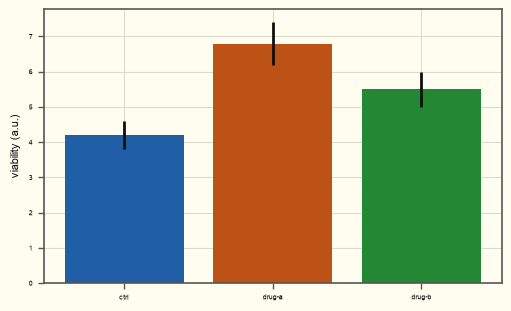

In [12]:
conditions = ["ctrl", "drug-a", "drug-b"]
means = [4.2, 6.8, 5.5]
sems  = [0.4, 0.6, 0.5]
xpos  = np.arange(len(conditions))          # numeric positions; labels set below

f, ax = plt.subplots(1, 1, figsize=(5, 3))
fp.bar(ax, xpos, means, series="viability", color=fx.CYCLE_LIGHT[:3])
fp.errorbar(ax, xpos, means, series="viability", yerr=sems,
            fmt="none", color=fx.FLEXOKI["black"], capsize=3)

ax.set_xticks(xpos); ax.set_xticklabels(conditions)
ax.set_ylabel("viability (a.u.)")
res = fp.save(f, './basic_example_output/mpl_bars_FLUXPLOT.svg',
              recipe=dict(params={"conditions": conditions}))

man = json.loads(Path(res.manifest).read_text())
s = man['series'][0]
print("series :", s['id'], "roles:", s['roles'])
print("svg    :", s['svg'])          # bars: [...per-bar ids...], errorbar: id

## Polar plot

Polar axes swap the rectangular scaffold for a circular one: the outer border is a `'polar'` spine (matplotlib keys polar spines `polar`/`start`/`end`/`inner`, not `bottom`/`left`), the theta grid is spokes, and the radial grid is rings. Fluxplot tags all of it the same way it tags a rectangular plot.

### Traditional Way

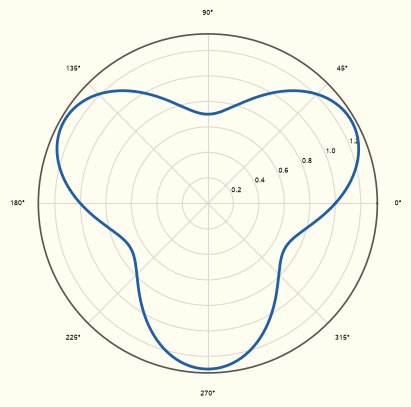

In [13]:
# a polar line — three petals; the scaffold (outer circle, spokes, rings) is anonymous
theta = np.linspace(0, 2 * np.pi, 200)
petals = 1 + 0.3 * np.sin(3 * theta)

f, ax = plt.subplots(1, 1, figsize=(4, 4), subplot_kw={"projection": "polar"})
ax.plot(theta, petals)
f.savefig('./basic_example_output/mpl_polar_VANILLA.svg', transparent=True)

### Fluxplot Way

Same one-word change. The outer circle becomes `axis.x.spine` (it runs along theta, the same convention that makes the bottom spine an x-spine), and every theta/r tick label and gridline is addressable.

spine       : ['axis.x.spine']
theta labels: ['axis.x.ticklabel.0', 'axis.x.ticklabel.1', 'axis.x.ticklabel.2', 'axis.x.ticklabel.3'] …
radial grid : ['axis.y.gridline.0', 'axis.y.gridline.1', 'axis.y.gridline.2', 'axis.y.gridline.3'] …


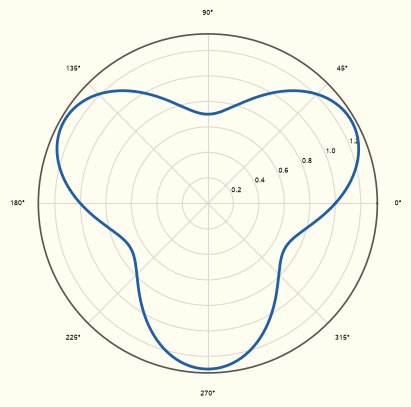

In [14]:
# same plot, tagged — the circular scaffold is now addressable by name
f, ax = plt.subplots(1, 1, figsize=(4, 4), subplot_kw={"projection": "polar"})
fp.line(ax, theta, petals, series="petals")
res = fp.save(f, './basic_example_output/mpl_polar_FLUXPLOT.svg',
              recipe=dict(params={"lobes": 3, "n_samples": 200}))

scaffold = [i for i in re.findall(r'id="([^"]+)"', Path(res.svg).read_text())
            if i.startswith('axis.')]
print("spine       :", [i for i in scaffold if 'spine' in i])
print("theta labels:", [i for i in scaffold if i.startswith('axis.x.ticklabel')][:4], '…')
print("radial grid :", [i for i in scaffold if i.startswith('axis.y.gridline')][:4], '…')

## Seaborn, the easy way: `fp.tag_seaborn`

Earlier we hand-tagged the seaborn lineplot to show the mechanics. But so much science is done in seaborn that fluxplot ships a helper that does the whole thing in **one line**:

```python
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", ax=ax)
fp.tag_seaborn(ax)          # ← that's it
```

Call it **right after** the seaborn call (and before any raw-matplotlib touches you want to tag yourself). It inspects what seaborn drew on the axes and names it, mapping seaborn's artists onto fluxplot roles:

| seaborn call | tagged as |
|---|---|
| `lineplot` (mean line + CI band) | `line` + `area` per hue |
| `scatterplot`, `regplot` points | `point` (per-point addressable) |
| `barplot`, `countplot`, `histplot` | `bar` (+ `errorbar` for barplot's error bars) |
| `kdeplot`, `regplot` fit line | `line` |

Series names come from the legend (in hue order — seaborn's own draw order), or you can pass `series=[...]` to name them yourself. It returns a dict of `{series: [roles tagged]}` so you can see exactly what happened. It skips anything you already tagged (so it composes with the `fp.*` helpers), and it deliberately **doesn't guess** at things it can't pin down confidently — those still become addressable `extra.*` elements via `fp.save`'s orphan sweep.

scatterplot → {'tip': ['point']}
barplot    → {'Male': ['bar', 'errorbar', 'errorbar', 'errorbar', 'errorbar'], 'Female': ['bar', 'errorbar', 'errorbar', 'errorbar', 'errorbar']}
manifest series: [('male', ['bar', 'errorbar']), ('female', ['bar', 'errorbar'])]


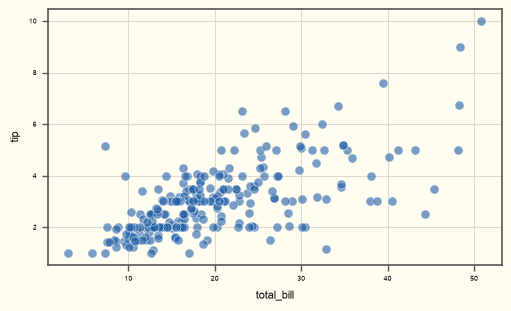

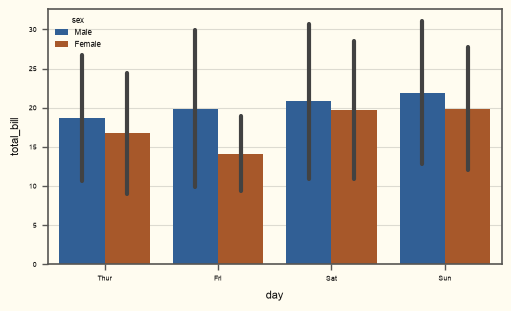

In [15]:
tips = sns.load_dataset("tips")

# a scatterplot → one addressable point cloud
f, ax = plt.subplots(1, 1, figsize=(5, 3))
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=ax, alpha=0.6)
print("scatterplot →", fp.tag_seaborn(ax))
fp.save(f, './basic_example_output/sns_scatter_FLUXPLOT.svg', recipe=dict(params={"dataset": "tips"}))

# a grouped barplot with SD error bars → bars + errorbars, one series per hue level
f, ax = plt.subplots(1, 1, figsize=(5, 3))
sns.barplot(data=tips, x="day", y="total_bill", hue="sex", errorbar="sd", ax=ax)
print("barplot    →", fp.tag_seaborn(ax))
res = fp.save(f, './basic_example_output/sns_bars_FLUXPLOT.svg', recipe=dict(params={"dataset": "tips"}))

man = json.loads(Path(res.manifest).read_text())
print("manifest series:", [(s['id'], s['roles']) for s in man['series']])

## Multi-panel figures: one plot per file

A very common situation: you've built a grid with `f, axs = plt.subplots(3, 2, figsize=...)` and you want it in Flux. Here the fluxplot answer is a little different from what you might expect, and it's worth understanding why.

**Fluxplot's unit is one plot, not one figure.** Its job is to make a *single* semantic plot; **composing several plots into a multi-panel figure is Flux Figure's job** — that's the tool where you arrange panels, label them a/b/c, share legends, and align axes, all non-destructively. So the idiomatic pattern is:

> **Draw each panel as its own figure and `fp.save` it to its own file** — then compose those files into a multi-panel figure in Flux Figure.

That gives you, per panel, a clean manifest with its own correct coordinate mapping — which means each panel stays independently **restylable, animatable, and morphable** once composed (e.g. Flux Slide can morph just panel *c* while the others hold). If you instead saved the whole `3×2` grid to a single SVG, it would render and every series would still be tagged, but the panels would share one plot-area coordinate capture — so per-panel data-space morphs wouldn't work. Hence: **one plot per file.**

Concretely, it's the same loop you'd already write — just create the figure *inside* it and save each one:

In [16]:
# six related channels we'd normally cram into plt.subplots(3, 2)
t = np.linspace(0, 6, 120)
channels = {
    "alpha": np.sin(t),
    "beta":  np.cos(t),
    "gamma": np.sin(2 * t),
    "delta": np.sin(t) * np.exp(-t / 6),
    "theta": np.cos(2 * t),
    "mu":    np.sin(t / 2),
}

# one figure per channel → one semantic file per panel, ready to compose in Flux Figure
saved = []
for name, wave in channels.items():
    f, ax = plt.subplots(1, 1, figsize=(4, 2.5))
    fp.line(ax, t, wave, series=name)
    ax.set_xlabel("time (s)"); ax.set_ylabel(f"{name} (µV)")
    res = fp.save(f, f'./basic_example_output/panel_{name}.svg',
                  recipe=dict(params={"channel": name}))
    saved.append(Path(res.svg).name)
    plt.close(f)   # we don't need to keep every panel figure open

print(f"wrote {len(saved)} independent semantic plots:")
for name in saved:
    print("  ", name, "(+ .fluxplot.json + .recipe.json)")
# → import all six into one Flux figure; each panel stays independently addressable

wrote 6 independent semantic plots:
   panel_alpha.svg (+ .fluxplot.json + .recipe.json)
   panel_beta.svg (+ .fluxplot.json + .recipe.json)
   panel_gamma.svg (+ .fluxplot.json + .recipe.json)
   panel_delta.svg (+ .fluxplot.json + .recipe.json)
   panel_theta.svg (+ .fluxplot.json + .recipe.json)
   panel_mu.svg (+ .fluxplot.json + .recipe.json)


## Where these files go: Flux

Each `fp.save()` above wrote a trio into `basic_example_output/` — `*.svg` + `*.fluxplot.json` + `*.recipe.json`. Those three siblings travel together into a Flux project (conventionally its `plots/` folder), and from there:

- **Flux Figure** imports each plot as a panel of a composed figure. Because the SVG is inlined, every tagged node is live: click a part, restyle it, and the override is stored **keyed by semantic id** — regenerate the plot and your hand-tuning re-attaches. You can sanity-check any plot with `flux validate-plot plots/myplot.svg`, which verifies that every id the manifest references really exists in the SVG.
- **Flux Slide** embeds figures into talks. One-click build animations follow the manifest's `build.order` with per-role presets (lines draw on, points stagger in), and the signature **morph** tweens two versions of a plot in *data space* — correct even across log axes — using the per-axis anchors you saw in example 1.
- **Regeneration.** In a real analysis this code lives in a `.py` script, and you save like this:

  ```python
  p = fp.params({"test": "t-test", "n": 100})        # tunables, overridable from outside
  fp.save(fig, "plots/myplot.svg",
          recipe=dict(script=__file__, params=p, inputs=["data/mydata.csv"]))
  ```

  The recipe then records the interpreter, script, params, and input hashes (as relative paths), which makes `flux rerun-plot plots/myplot.recipe.json --test mann-whitney` — and the in-app **Regenerate** button — a real operation: your script re-runs with the overridden params and re-emits the plot in place, and every downstream restyle / animation / caption survives because the ids didn't change. (A notebook isn't a script file, so above we recorded `params` only: provenance, but not auto-re-runnable.)

### The house style

Everything above is drawn in the **Flux house style** — that's the one-liner near the top of this notebook:

```python
from fluxplot import style as fx
fx.use_light()          # call before creating figures (fx.use_dark() for dark)
```

It's the reason these plots have the Flexoki palette, the clean typography, and the despined look. It is **completely independent of the semantics** — apply it to any matplotlib plotting, `fp.*`-tagged or a throwaway `plt.plot`, and everything comes out looking like one coherent set. For real Flux work it's the recommended default. (We turned it on globally here, so it styles the "traditional" plots too — each traditional/fluxplot pair still matches, because both sides render under the same active style.)